In [ ]:
!pip install transformers
!pip install datasets
!pip install scikit-learn
!pip install pandas
!pip install torch

In [ ]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import Trainer, TrainingArguments
from datasets import Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Fake.csv to Fake.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving True.csv to True.csv


In [ ]:
import pandas as pd

fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

fake["label"] = 0
true["label"] = 1

df = pd.concat([fake, true])

print(df.head())
print(df["label"].value_counts())

                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  label  
0  December 31, 2017      0  
1  December 31, 2017      0  
2  December 30, 2017      0  
3  December 29, 2017      0  
4  December 25, 2017      0  
label
0    23481
1    21417
Name: count, dtype: int64


In [ ]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['text'],
    df['label'],
    test_size=0.2,
    random_state=42
)

In [ ]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
def tokenize_function(texts):
    return tokenizer(
        texts,
        padding='max_length',
        truncation=True,
        max_length=128
    )

In [ ]:
train_encodings = tokenize_function(list(train_texts))
test_encodings = tokenize_function(list(test_texts))

In [ ]:
train_dataset = Dataset.from_dict({
    'input_ids': train_encodings['input_ids'],
    'attention_mask': train_encodings['attention_mask'],
    'label': list(train_labels)
})

test_dataset = Dataset.from_dict({
    'input_ids': test_encodings['input_ids'],
    'attention_mask': test_encodings['attention_mask'],
    'label': list(test_labels)
})

In [ ]:
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

In [ ]:
trainer.train()

Step,Training Loss
500,0.029189
1000,0.003193
1500,0.005129
2000,0.001770
2500,0.001313
3000,0.000021
3500,0.001391
4000,0.000388
4500,0.001311
5000,0.000106


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=6735, training_loss=0.0033224660802615978, metrics={'train_runtime': 3403.9515, 'train_samples_per_second': 31.656, 'train_steps_per_second': 1.979, 'total_flos': 7087817164815360.0, 'train_loss': 0.0033224660802615978, 'epoch': 3.0})

In [ ]:
predictions = trainer.predict(test_dataset)
preds = predictions.predictions.argmax(axis=1)

In [ ]:
print(classification_report(test_labels, preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4733
           1       1.00      1.00      1.00      4247

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



In [ ]:
cm = confusion_matrix(test_labels, preds)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[4733    0]
 [   0 4247]]


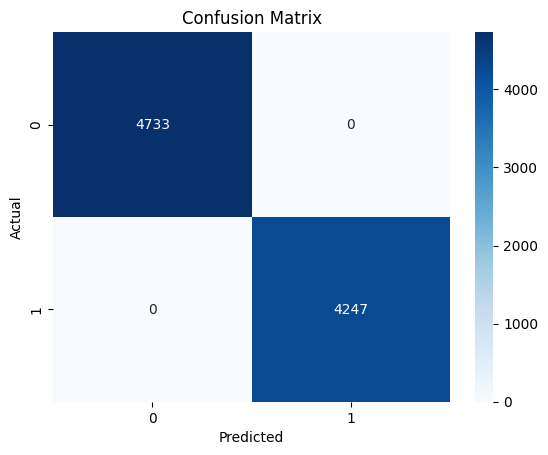

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(test_labels, preds)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
model.save_pretrained("fake_news_bert_model")
tokenizer.save_pretrained("fake_news_bert_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('fake_news_bert_model/tokenizer_config.json',
 'fake_news_bert_model/tokenizer.json')

In [ ]:
import torch
import torch.nn.functional as F

def predict_news(text):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {key: value.to(device) for key, value in inputs.items()}
    model.to(device)

    outputs = model(**inputs)

    probs = F.softmax(outputs.logits, dim=1)

    prediction = torch.argmax(probs)

    fake_prob = probs[0][0].item()
    real_prob = probs[0][1].item()

    if prediction == 1:
        print("Prediction: Real News")
    else:
        print("Prediction: Fake News")

    print(f"Fake probability: {fake_prob:.4f}")
    print(f"Real probability: {real_prob:.4f}")

Example test:

In [ ]:
predict_news("Government announces new economic policy today")

Prediction: Fake News
Fake probability: 1.0000
Real probability: 0.0000


In [ ]:
predict_news("Scientists discovered a new cancer treatment")
predict_news("Aliens landed in New York yesterday")
predict_news("Government announces new tax reforms")

Prediction: Fake News
Fake probability: 0.9999
Real probability: 0.0001
Prediction: Fake News
Fake probability: 1.0000
Real probability: 0.0000
Prediction: Fake News
Fake probability: 0.9996
Real probability: 0.0004


In [ ]:
import pandas as pd

# Create dataframe for analysis
analysis_df = pd.DataFrame({
    "text": test_texts,
    "actual_label": test_labels,
    "predicted_label": preds
})

# Find misclassified samples
errors = analysis_df[analysis_df["actual_label"] != analysis_df["predicted_label"]]

print("Total incorrect predictions:", len(errors))

# Show first 5 errors
errors.head(5)

Total incorrect predictions: 0


,text,actual_label,predicted_label


In [ ]:
if len(errors) == 0:
    print("No misclassified samples found. Model predicted all test samples correctly.")
else:
    display(errors.head(5))

No misclassified samples found. Model predicted all test samples correctly.


Model Improvement step by tuning learning rate

In [ ]:
from transformers import TrainingArguments

training_args_lr = TrainingArguments(
    output_dir="./results_lr",
    learning_rate=5e-5,   # tuned learning rate
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3
)

In [ ]:
trainer_lr = Trainer(
    model=model,
    args=training_args_lr,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

trainer_lr.train()

Step,Training Loss
500,0.000000
1000,0.000000
1500,0.018877
2000,0.030415
2500,0.007689
3000,0.003955
3500,0.002673
4000,0.002559
4500,0.003373
5000,0.000963


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Step,Training Loss
500,0.000000
1000,0.000000
1500,0.018877
2000,0.030415
2500,0.007689
3000,0.003955
3500,0.002673
4000,0.002559
4500,0.003373
5000,0.000963


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=6735, training_loss=0.005421179510710189, metrics={'train_runtime': 3606.8245, 'train_samples_per_second': 29.875, 'train_steps_per_second': 1.867, 'total_flos': 7087817164815360.0, 'train_loss': 0.005421179510710189, 'epoch': 3.0})

In [ ]:
predictions_lr = trainer_lr.predict(test_dataset)

preds_lr = predictions_lr.predictions.argmax(axis=1)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(test_labels, preds_lr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4733
           1       1.00      1.00      1.00      4247

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



In [ ]:
from sklearn.metrics import accuracy_score

accuracy_before = accuracy_score(test_labels, preds)
accuracy_after = accuracy_score(test_labels, preds_lr)

print("Accuracy Before Tuning:", accuracy_before)
print("Accuracy After Tuning:", accuracy_after)

Accuracy Before Tuning: 1.0
Accuracy After Tuning: 0.9997772828507795
